In [192]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np

In [193]:
# Loading train dataset (image's id_codes and corresponding diagnoses)
train_df = pd.read_csv('../data/raw/aptos2019/train.csv')
print(f'Train dataset:\n{train_df.head()}')

Train dataset:
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [194]:
# Checking if the number od rows in loaded dataset is equal
# to the number of files in the train images directory
print(f'Number of rows in train.csv: {len(train_df)}')
DIR_TRAIN = '../data/raw/aptos2019/train_images'
print(f'Number of files in /train_images: '
      f'{len([name for name in os.listdir(DIR_TRAIN)
              if os.path.isfile(os.path.join(DIR_TRAIN, name))])}')

Number of rows in train.csv: 3662
Number of files in /train_images: 3662


In [195]:
# Looking at dtypes and checking for NaN values
print(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id_code    3662 non-null   str  
 1   diagnosis  3662 non-null   int64
dtypes: int64(1), str(1)
memory usage: 57.3 KB
None


In [196]:
# Checking for anomalies
print(train_df.describe())

         diagnosis
count  3662.000000
mean      1.126980
std       1.298409
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       4.000000


In [197]:
# Checking for duplicates
print(f'Number of duplicates: {train_df['id_code'].duplicated().sum()}')

Number of duplicates: 0


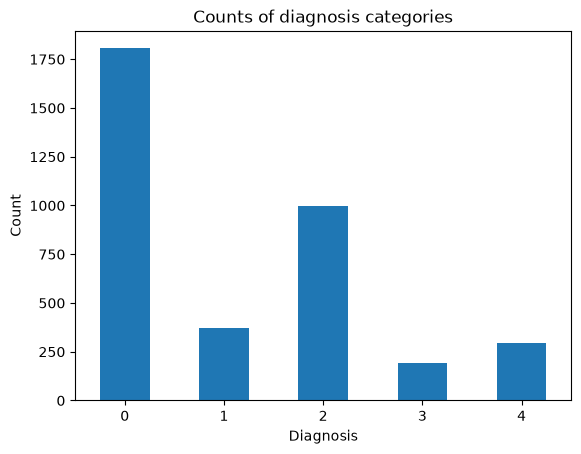

In [198]:
# Bar chart of diagnosis categories
counts = train_df['diagnosis'].value_counts().sort_index()
counts.plot(kind='bar')
plt.xlabel('Diagnosis')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.title('Counts of diagnosis categories')
plt.show()

In [199]:
# How big is the disbalance?
print('Proportion of diagnosis categories:')
print(train_df['diagnosis'].value_counts(normalize=True))

Proportion of diagnosis categories:
diagnosis
0    0.492900
2    0.272802
1    0.101038
4    0.080557
3    0.052703
Name: proportion, dtype: float64


We can see that categories 0 (No DR) and 2 (Moderate) are dominant in the dataset. Due to the class imbalance and the ordinal nature of the task:
 1. Quadratic Weighted Kappa will be used as the primary metric, as it accounts for the distance between classes (confusing 0 with 4 is worse than confusing 0 with 1).
2. For loss function class weighted CrossEntropyLoss or Focal Loss will be considered, as they help when one class has many more samples than another. It stops the model from simply guessing the majority class to get a high overall accuracy.

In [200]:
# Checking sizes of the images in the train dataset
np.random.seed(42)
for i in range(5):
    image_id = np.random.choice(train_df['id_code'])
    img_path = os.path.join(DIR_TRAIN, f'{image_id}.png')
    img = Image.open(img_path)
    print(f'Image_{i+1} size: {img.size}')

Image_1 size: (2588, 1958)
Image_2 size: (3216, 2136)
Image_3 size: (2416, 1736)
Image_4 size: (2416, 1736)
Image_5 size: (1050, 1050)


Images in the train dataset are of different sizes, so we will need to resize them before feeding to the network. Given the presence of both rectangular (1-4) and square (5) images, it is also necessary to use padding to avoid distorting proportions.

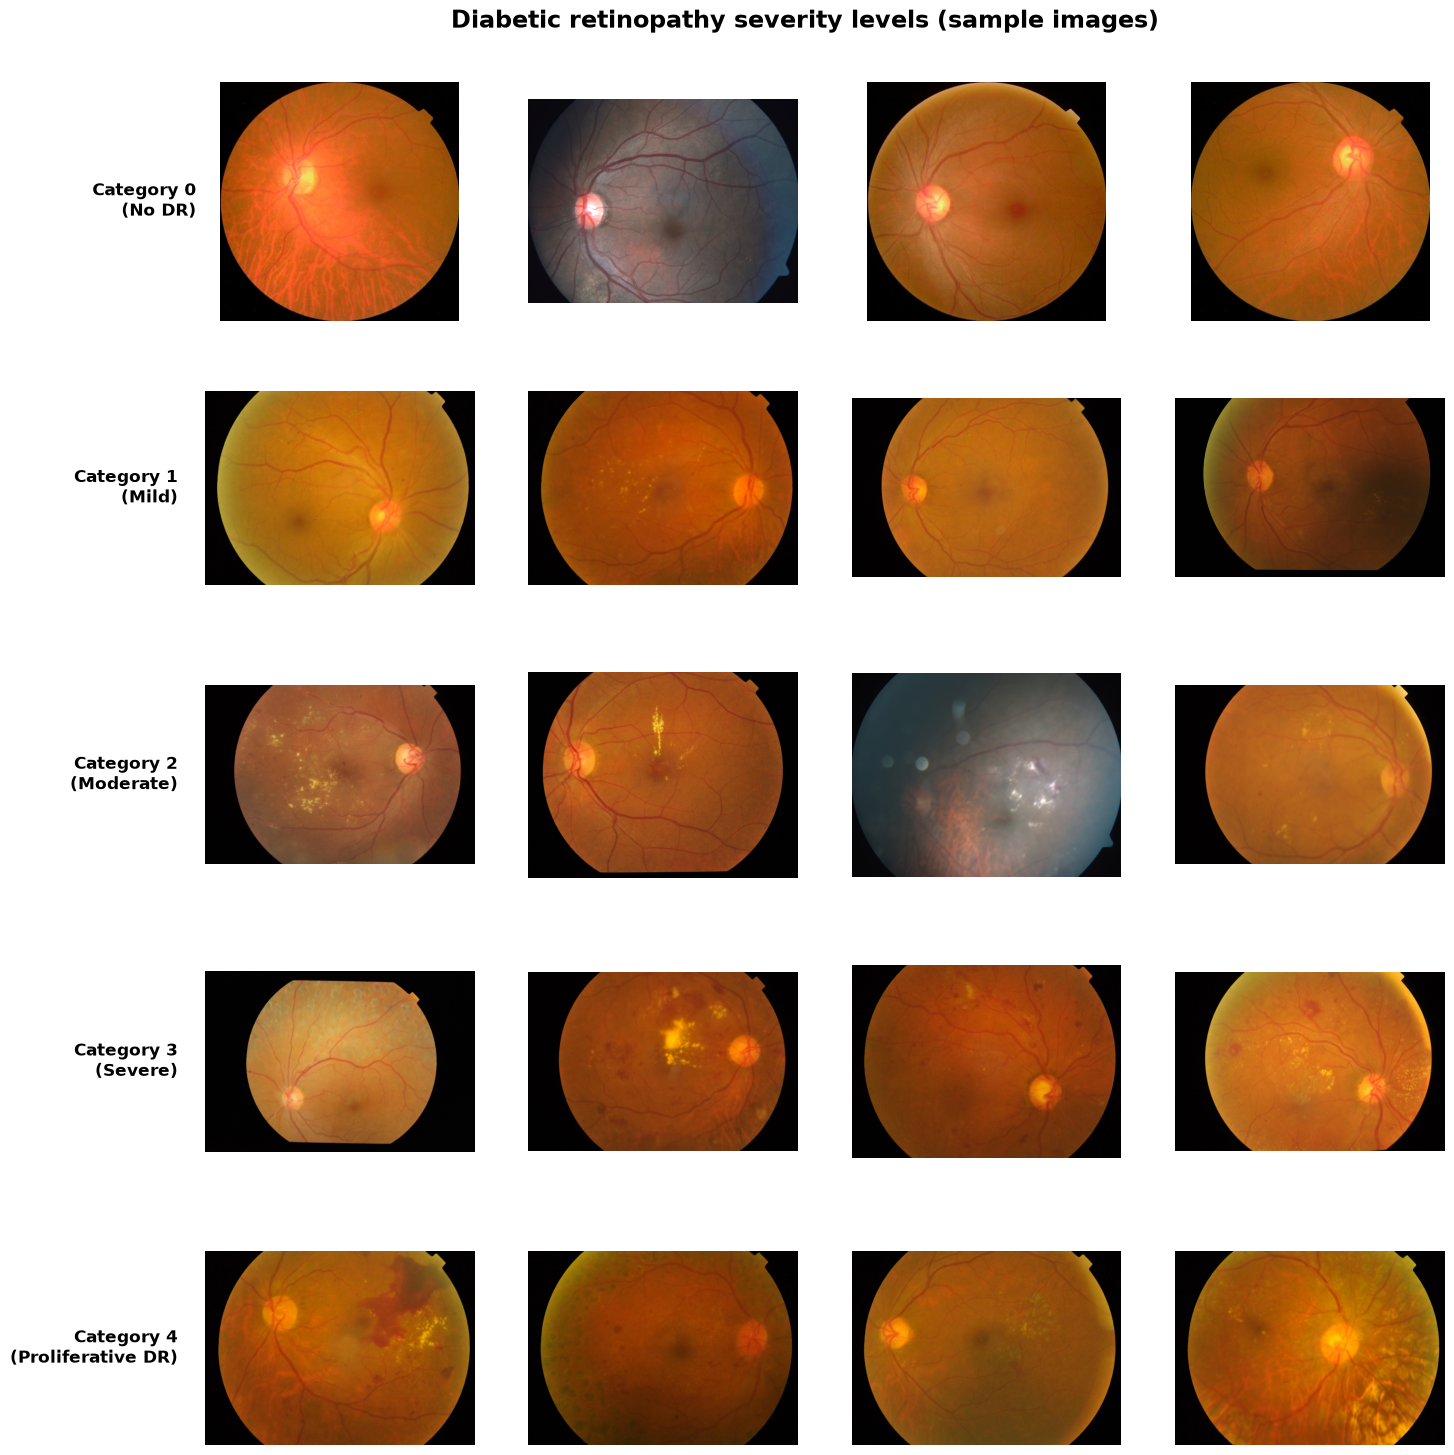

In [201]:
# Looking at several examples of each category
severity = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative DR'
}
np.random.seed(42)
fig, axes = plt.subplots(5, 4, figsize=(16, 18))
for cat in range(0, 5):
    filtered_df = train_df[train_df['diagnosis'] == cat]
    random_ids = np.random.choice(filtered_df['id_code'].values, size=4, replace=False)

    for i, image_id in enumerate(random_ids):
        ax = axes[cat, i]
        ax.axis('off')
        img_path = os.path.join(DIR_TRAIN, f'{image_id}.png')
        img = Image.open(img_path)
        ax.imshow(img)
        if i == 0:
            ax.text(-0.1, 0.5, f'Category {cat}\n({severity[cat]})',
                    transform=ax.transAxes, fontsize=12,
                    ha='right', va='center', weight='bold')
fig.suptitle('Diabetic retinopathy severity levels (sample images)',
             fontsize=17, weight='bold', y=0.92)
plt.show()

We can see that:
1. Some images have a noticeably different color balance — grayish-blue (e.g., the second one in category 0). This may be due to differences in cameras or shooting conditions. Contrast or brightness normalization may be required.
2. Images have black borders of different sizes (a form of noise), these edges will need to be cropped.
3. All images have a small mark in the corner (top right for orange images and bottom right for grayish-blue). It may be a signal that indicates two different sources or cameras for the images. This raises an important question: does the camera type (orange vs. grayish-blue) correlate with a specific diagnosis class? If, for instance, all gray-blue images happen to appear more frequently in a specific class, the model might learn to recognize the image source rather than the disease itself (this is a phenomenon known in medical ML as "shortcut learning", where a model exploits simple, unintended patterns in training data to make predictions).

In [202]:
# Displaying a few examples of the "gray-blue" type and see whether they are evenly
# distributed across all diagnosis categories or concentrated in specific classes.
# TODO

In [203]:
# Checking sizes of train images
file_names = [name for name in os.listdir(DIR_TRAIN)]
file_sizes = [os.path.getsize(os.path.join(DIR_TRAIN, name))
         for name in file_names]
print('Description of file sizes in the train dataset:')
print(pd.DataFrame(file_sizes).describe())

Description of file sizes in the train dataset:
                  0
count  3.662000e+03
mean   2.349280e+06
std    1.762452e+06
min    2.217370e+05
25%    1.003996e+06
50%    1.934951e+06
75%    2.846848e+06
max    7.674292e+06


We observe a healthy distribution of file sizes. Average size is ~2.35 MB (Median: ~1.93 MB), no severe skewness. Range is from ~221 KB to ~7.67 MB.

### Key observations

1. Class imbalance + ordinal nature -> Quadratic Weighted Kappa as primary metric and considering class weighted CrossEntropyLoss or Focal Loss.
2. Pad and resize images before feeding to the network as they are of difference shapes.
3. Contrast or brightness normalization may be required due to different color balance of some images.
4. Potential confounding factor due to the two image types (source/camera), check correlation with labels before modeling.